### Matthew Riddell 
### D00245674
### MSc in Data Analytics
### Dissertation
### Linear Regressions Notebook

Linear Regressions


### Link to each Dataset:

### ECI Petitions:
#### 2024

- ECI 01: https://citizens-initiative.europa.eu/initiatives/details/2024/000001_en Ban on conversion practices in the European Union
- ECI 02: https://citizens-initiative.europa.eu/initiatives/details/2024/000002_en European Citizens' Initiative in Defence of Agriculture and Rural Economy in Europe
- ECI 03: https://citizens-initiative.europa.eu/initiatives/details/2024/000004_en My Voice, My Choice: For Safe And Accessible Abortion
- ECI 04: https://citizens-initiative.europa.eu/initiatives/details/2024/000006_en Air-Quotas
- ECI 05: https://citizens-initiative.europa.eu/initiatives/details/2024/000007_en Stop Destroying Videogames
- ECI 06: https://citizens-initiative.europa.eu/initiatives/details/2024/000008_en Stop Cruelty Stop Slaughter
- ECI 07: https://citizens-initiative.europa.eu/initiatives/details/2024/000009_en STOP FAKE FOOD: ORIGIN ON LABEL
- ECI 08: https://citizens-initiative.europa.eu/initiatives/details/2024/000010_en ECI for a Water-Smart and Resilient Europe
- ECI 09: https://citizens-initiative.europa.eu/initiatives/details/2024/000011_en PsychedeliCare

#### 2023

- ECI 10: https://citizens-initiative.europa.eu/initiatives/details/2023/000001_en Stop torture and inhuman treatment at Europe’s borders
- ECI 11: https://citizens-initiative.europa.eu/initiatives/details/2023/000002_en Ensuring a dignified reception of migrants in Europe
- ECI 12: https://citizens-initiative.europa.eu/initiatives/details/2023/000003_en End The Horse Slaughter Age
- ECI 13: https://citizens-initiative.europa.eu/initiatives/details/2023/000004_en Connecting all European capitals and people through a high-speed train network
- ECI 14: https://citizens-initiative.europa.eu/initiatives/details/2023/000005_en Effective implementation of the concept of judicial precedent in EU countries
- ECI 15: https://citizens-initiative.europa.eu/initiatives/details/2023/000006_en Taxing great wealth to finance the ecological and social transition
- ECI 16: https://citizens-initiative.europa.eu/initiatives/details/2023/000007_en Preservation and development of Ukrainian culture, education, language, and traditions in EU states
- ECI 17: https://citizens-initiative.europa.eu/initiatives/details/2023/000008_en EU Live Bus Stop Info
- ECI 18: https://citizens-initiative.europa.eu/initiatives/details/2023/000009_en Trust and Freedom
- ECI 19: https://citizens-initiative.europa.eu/initiatives/details/2023/000011_en Creation of a European Environment Authority

#### 2022

- ECI 20: https://citizens-initiative.europa.eu/initiatives/details/2022/000001_en Win It On The Pitch 
- ECI 21: https://citizens-initiative.europa.eu/initiatives/details/2022/000002_en Fur Free Europe
- ECI 22: https://citizens-initiative.europa.eu/initiatives/details/2022/000003_en End The Slaughter Age
- ECI 23: https://citizens-initiative.europa.eu/initiatives/details/2022/000004_en Good Clothes, Fair Pay
- ECI 24: https://citizens-initiative.europa.eu/initiatives/details/2022/000007_en Protect the EU’s Rural Heritage, Food Security and Supply
- ECI 25: https://citizens-initiative.europa.eu/initiatives/details/2022/000008_en Focus on Specific Learning Disabilities on EU Level
- ECI 26: https://citizens-initiative.europa.eu/initiatives/details/2022/000009_en European Citizens’ Initiative for VEGAN MEAL
- ECI 27: https://citizens-initiative.europa.eu/initiatives/details/2022/000010_en European Day of "Whatever it Takes" 

### Worldstat Kaggle Dataset
https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023

### 2023 Global Development and Prosperity Index 
https://www.kaggle.com/datasets/tarktunataalt/2023-global-country-development-and-prosperity-index

### Media Literacy Index Dataset 2023
https://osis.bg/wp-content/uploads/2023/06/MLI-report-in-English-22.06.pdf

https://osis.bg/?p=4450&lang=en

### Mahara Portfolio:
https://mahara.dkit.ie/view/view.php?t=f816cb6da6dd833aaa2f

### Github Repository:
https://github.com/Matthew-Riddell/MSc-Dissertation

### Import Libraries

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

import scipy
from scipy import stats
import seaborn as sns

import os
import joblib

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Model Path 

Model path for exporting

In [70]:
model_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models"

### Output Path

In [71]:
output_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/outputs"

### Load Dataset

In [72]:
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/data/Prepared Datasets/"
file_name = "master_dataset.csv"
complete_file_name = file_path + file_name

In [73]:
master = pd.read_csv(complete_file_name)

In [74]:
master.head()

,Petition_ID,Petition_Name,Country,Genre,Year,Total_Signatures,Successful,Signatures,Signatures_Per_Capita,Population,Population_Density,GDP_Per_Capita,Unemployment,Tertiary_Enrollment,Life_Expectancy,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
0,eci_table_01,Ban Conversion Practices,Austria,Human Rights,2024,1128063,True,10724,0.001208,8877067.0,109,50277.275087,4.67,85.1,81.6,59,81.19,67.94,85.99,81.93
1,eci_table_01,Ban Conversion Practices,Belgium,Human Rights,2024,1128063,True,47459,0.004133,11484055.0,383,46116.699234,5.59,79.7,81.6,61,80.31,64.55,87.70,84.79
2,eci_table_01,Ban Conversion Practices,Bulgaria,Human Rights,2024,1128063,True,2386,0.000342,6975761.0,64,12328.404026,4.34,71.0,74.9,31,53.12,54.62,68.31,72.79
3,eci_table_01,Ban Conversion Practices,Croatia,Human Rights,2024,1128063,True,8574,0.002108,4067500.0,73,14853.239837,6.93,67.9,78.1,45,56.15,52.19,75.16,73.54
4,eci_table_01,Ban Conversion Practices,Cyprus,Human Rights,2024,1128063,True,696,0.000581,1198575.0,131,20494.877613,7.27,75.9,80.8,39,65.69,56.86,78.31,79.14


## Linear Regressions 1: Raw Signatures

## Model 1A

In [75]:
X = master[["Population", "GDP_Per_Capita"]]

y = master["Signatures"]

### VIF test on variables

In [76]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

         Variable       VIF
0           const  4.034801
1      Population  1.000004
2  GDP_Per_Capita  1.000004


In [77]:
X = sm.add_constant(X)

model_1A = sm.OLS(y, X).fit()

print(model_1A.summary())

                            OLS Regression Results                            
Dep. Variable:             Signatures   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     40.29
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           2.55e-17
Time:                        22:00:49   Log-Likelihood:                -8895.0
No. Observations:                 729   AIC:                         1.780e+04
Df Residuals:                     726   BIC:                         1.781e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -3808.0182   3591.857     -1.

### Linear Regression Model 1A - Evaluation

In [78]:
print("R²:", model_1A.rsquared)
print("Adjusted R²:", model_1A.rsquared_adj)
print("F-statistic:", model_1A.fvalue)
print("Model p-value:", model_1A.f_pvalue)

R²: 0.09990934679949715
Adjusted R²: 0.09742975822318733
F-statistic: 40.29271136108406
Model p-value: 2.546299206164381e-17


### Predictions

In [79]:
predictions_1A = model_1A.predict(X)

### RMSE

In [80]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(y, predictions_1A)
)

print(rmse)

48181.059394702716


### MAE

In [81]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y,
    predictions_1A
)

print(mae)

16630.70023552485


### Residual plots

In [82]:
residuals_1A = y - predictions_1A

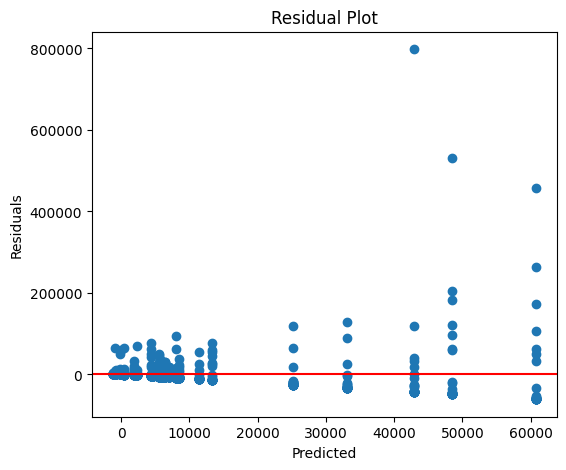

In [83]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_1A, residuals_1A)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

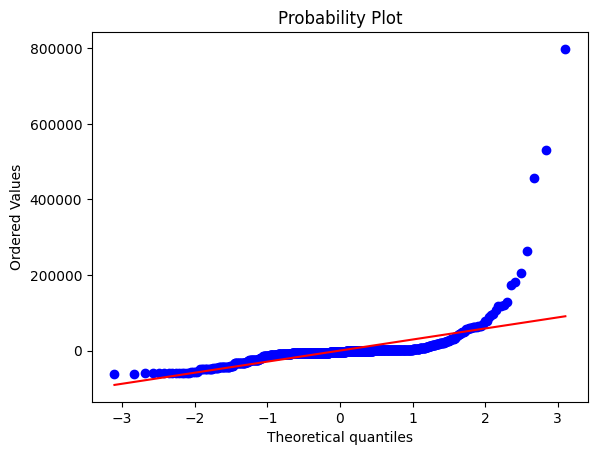

In [84]:
import scipy.stats as stats

stats.probplot(residuals_1A, dist="norm", plot=plt)

plt.show()

### Interpretations

### Export

In [ ]:
joblib.dump(
    model_1A,
    rf"{model_path}/regressions/regression_model_1a.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_1a.pkl']

## Model 1B

In [86]:
X = master[
    [
        "Population",
        "Population_Density",
        "Tertiary_Enrollment",
        "Life_Expectancy"
    ]
]

y = master["Signatures"]

In [87]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

              Variable          VIF
0                const  1049.647999
1           Population     1.111231
2   Population_Density     1.198212
3  Tertiary_Enrollment     1.110744
4      Life_Expectancy     1.296997


In [88]:
X = sm.add_constant(X)

model_1B = sm.OLS(y, X).fit()

print(model_1B.summary())

                            OLS Regression Results                            
Dep. Variable:             Signatures   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     19.97
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           1.30e-15
Time:                        22:10:08   Log-Likelihood:                -8895.2
No. Observations:                 729   AIC:                         1.780e+04
Df Residuals:                     724   BIC:                         1.782e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -4.785e+04    

In [89]:
print("R²:", model_1B.rsquared)
print("Adjusted R²:", model_1B.rsquared_adj)
print("F-statistic:", model_1B.fvalue)
print("Model p-value:", model_1B.f_pvalue)

R²: 0.09937624969017278
Adjusted R²: 0.09440042786525649
F-statistic: 19.971826401128602
Model p-value: 1.2960089454592907e-15
